# Analysing NYC Yellow Taxi Trips with PySpark
A beginner-friendly Big Data project applying ideas from *Introduction to Big Data*: the 5 Vs, structured vs unstructured data, HDFS, MapReduce and the Hadoop ecosystem.

**Dataset:** NYC TLC Yellow Taxi trip records, January 2024 (~3 million rows, Parquet) + taxi zone lookup.

## The 5 Vs of Big Data applied to this dataset
| V | In this dataset |
|---|---|
| **Volume** | ~3 million trips in one month; the full TLC archive is billions of rows |
| **Velocity** | Trips are recorded continuously and published monthly; a real system would stream them |
| **Variety** | Structured trip table (Parquet) + a CSV lookup; free text (a book) used in the MapReduce demo is *unstructured* |
| **Veracity** | Contains zero/negative fares, zero distances and impossible times - cleaning needed |
| **Value** | Reveals demand patterns, busy zones and tipping behaviour for planning and pricing |

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")
import pandas as pd
import analysis as an
import wordcount_mapreduce as wc
from spark_session import get_spark
from IPython.display import Image, display
spark = get_spark()
CH = "../outputs/charts/"
print("Spark", spark.version)

Spark 4.2.0


## MapReduce demo: word count
The same job written twice: pure Python with explicit *map / shuffle / reduce* phases, then Spark RDD (`flatMap -> map -> reduceByKey`).

Implementations agree: True | distinct words: 2575 | total: 27427


,word,count
0,alice,399
1,little,129
2,know,87
3,like,85
4,again,83
5,herself,83
6,went,83
7,when,79
8,queen,76
9,thought,74


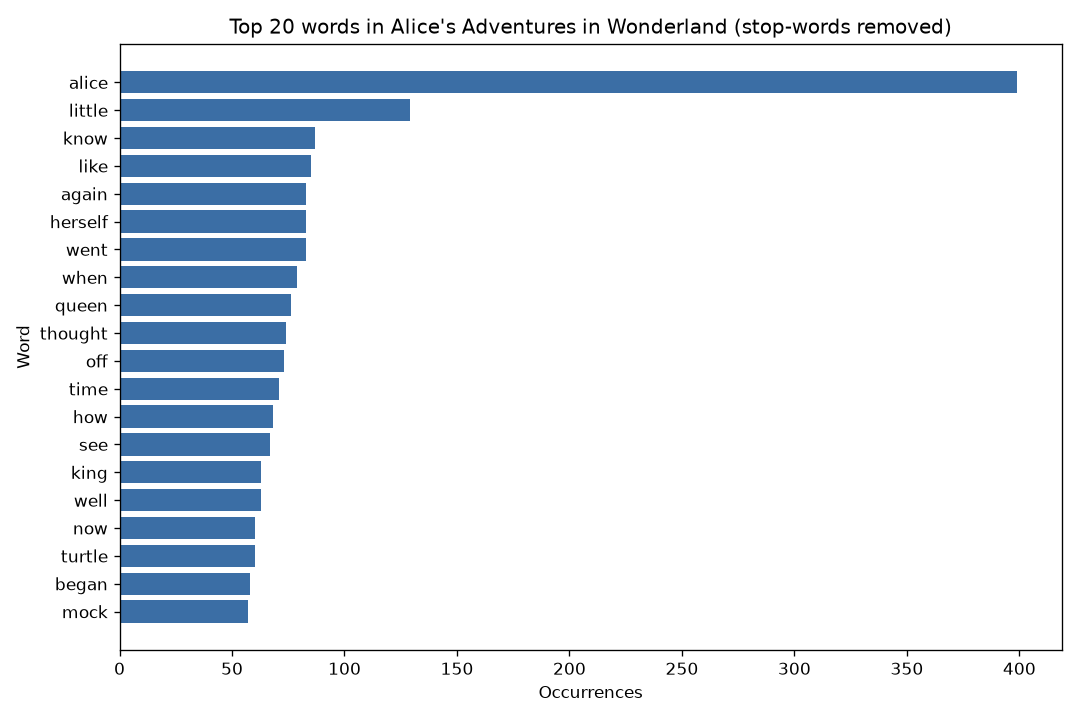

In [2]:
book = an.ROOT / "data" / "raw" / "alice.txt"
if not book.exists():
    book = an.ROOT / "data" / "sample" / "alice.txt"
lines = wc.strip_gutenberg(book.read_text(encoding="utf-8-sig")).splitlines()
py = wc.wordcount_python(lines)
sp = wc.wordcount_spark(spark, lines)
print("Implementations agree:", py == sp, "| distinct words:", len(py), "| total:", sum(py.values()))
top = pd.DataFrame(wc.top_n(py, 20), columns=["word", "count"])
display(top.head(10))
display(Image(CH + "wordcount_top20.png"))

**Insight:** 'alice' dominates (399 mentions) and the rest are story words like *queen*, *king*, *turtle*. Both implementations give identical counts; Spark just distributes the same three phases across partitions.

## Loading the data

In [3]:
trips_path, zones_path = an.default_paths()
print("Using:", trips_path)
trips = an.load_trips(spark, trips_path)
zones = an.load_zones(spark, zones_path)
trips.printSchema()
print("Rows:", trips.count())
an.null_counts(trips)

Using: C:\Users\HP\Desktop\Analysing a Large Public Dataset with Hadoop or Spark\bigdata-spark-analysis\data\raw\yellow_tripdata_2024-01.parquet


root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



Rows: 2964624


,column,nulls
0,VendorID,0
1,tpep_pickup_datetime,0
2,tpep_dropoff_datetime,0
3,passenger_count,140162
4,trip_distance,0
5,RatecodeID,140162
6,store_and_fwd_flag,140162
7,PULocationID,0
8,DOLocationID,0
9,payment_type,0


Only `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge` and `Airport_fee` have nulls (about 140k each, ~4.7%).

## Cleaning
Remove rows with fare <= 0, distance <= 0, passenger_count <= 0 (or null), or dropoff before pickup.

In [4]:
clean, report = an.clean_trips(trips)
display(pd.DataFrame(list(report.items()), columns=["step", "rows"]))
clean = an.add_time_features(clean).cache()
removed = report["rows_before"] - report["rows_after"]
print(f"Removed {removed:,} rows ({removed / report['rows_before']:.1%})")

,step,rows
0,rows_before,2964624
1,fare_amount <= 0 (or null),38341
2,trip_distance <= 0 (or null),56569
3,passenger_count <= 0 (or null),30660
4,dropoff earlier than pickup (or null times),8
5,rows_after,2723797


Removed 240,827 rows (8.1%)


**Insight:** about 8% of rows were invalid, mostly zero-distance trips and non-positive fares. Veracity matters even in official data.

## 1. Trips by hour of day

Schema:
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



Row count: 2964624


               column  nulls
             VendorID      0
 tpep_pickup_datetime      0
tpep_dropoff_datetime      0
      passenger_count 140162
        trip_distance      0
           RatecodeID 140162
   store_and_fwd_flag 140162
         PULocationID      0
         DOLocationID      0
         payment_type      0
          fare_amount      0
                extra      0
              mta_tax      0
           tip_amount      0
         tolls_amount      0
improvement_surcharge      0
         total_amount      0
 congestion_surcharge 140162
          Airport_fee 140162


Cleaning report: {'rows_before': 2964624, 'fare_amount <= 0 (or null)': 38341, 'trip_distance <= 0 (or null)': 56569, 'passenger_count <= 0 (or null)': 30660, 'dropoff earlier than pickup (or null times)': 8, 'rows_after': 2723797}


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
trips,69189,45376,31932,20549,12783,15629,35583,74314,105119,119392,...,171272,176971,178411,191258,195918,170588,149263,148387,130534,97345


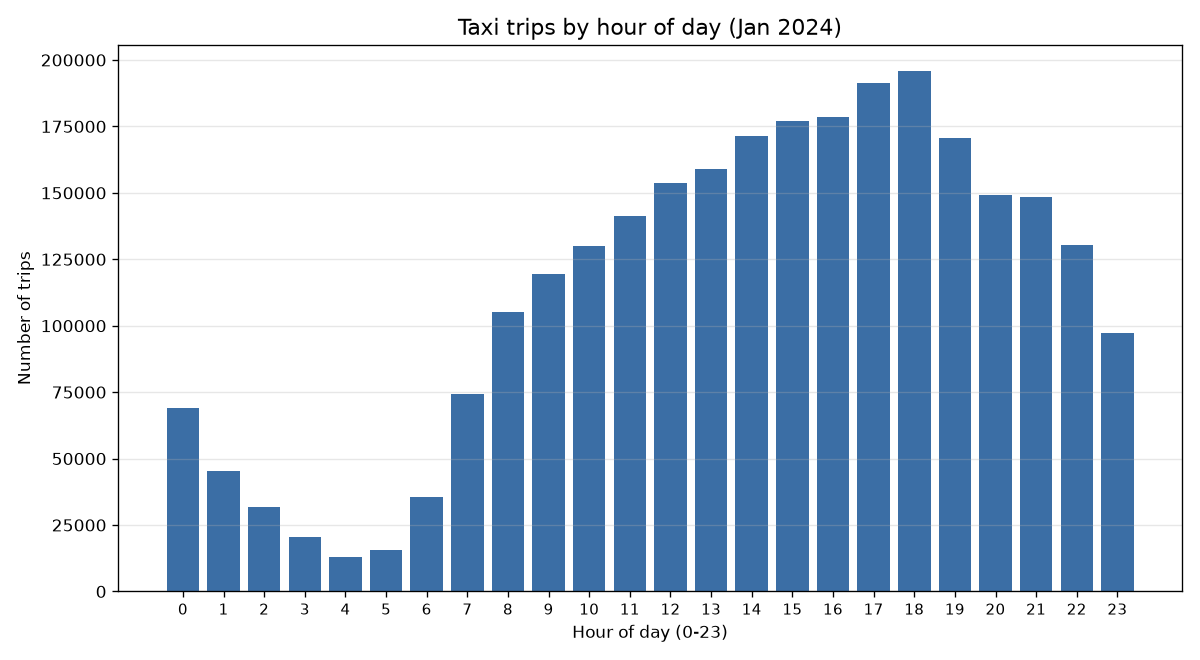

In [5]:
res = an.run_all(spark)   # runs every job, writes CSVs + charts
display(res["hour"].T)
display(Image(CH + "trips_by_hour.png"))

**Insight:** Demand peaks at 18:00 (about 196k trips) and bottoms out at 04:00 (about 13k) - a 15x swing.

## 2. Trips by day of week

,pickup_day,trips
0,Mon,372417
1,Tue,425916
2,Wed,458785
3,Thu,397445
4,Fri,378569
5,Sat,384258
6,Sun,306407


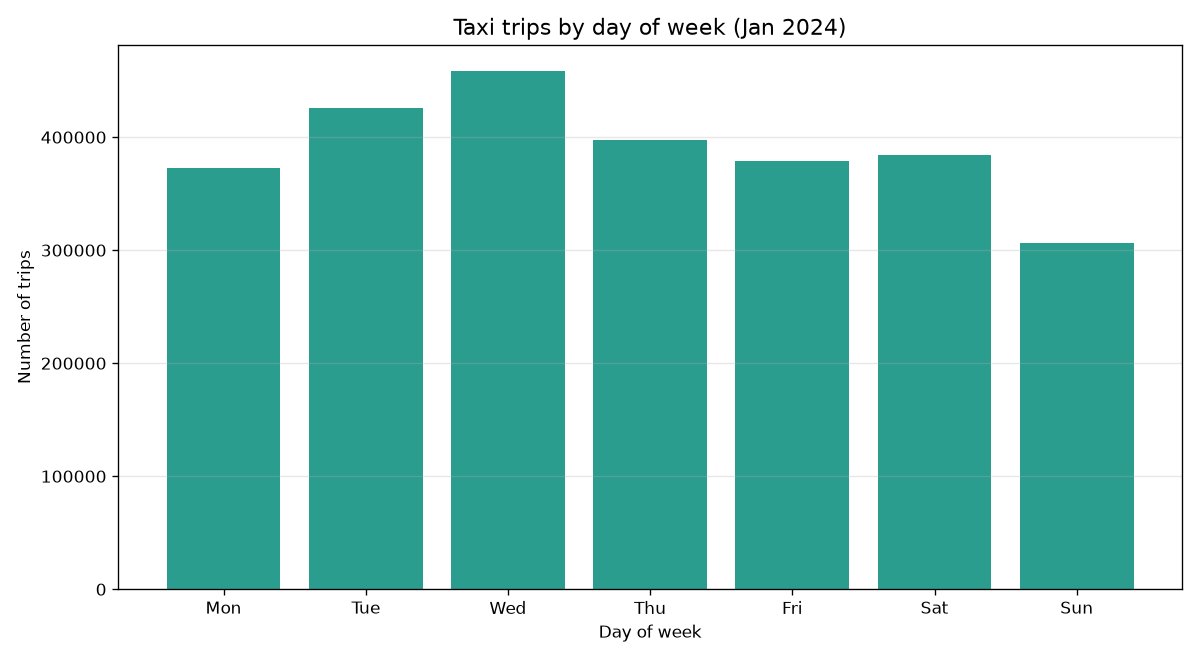

In [6]:
display(res["day"]); display(Image(CH + "trips_by_day.png"))

**Insight:** Wednesday is busiest (about 459k trips) and Sunday quietest (about 306k).

## 3. Top 10 pickup zones

,PULocationID,Zone,Borough,trips
0,132,JFK Airport,Queens,136959
1,237,Upper East Side South,Manhattan,135461
2,161,Midtown Center,Manhattan,134967
3,236,Upper East Side North,Manhattan,128098
4,162,Midtown East,Manhattan,101251
5,186,Penn Station/Madison Sq West,Manhattan,99456
6,230,Times Sq/Theatre District,Manhattan,98960
7,142,Lincoln Square East,Manhattan,97633
8,138,LaGuardia Airport,Queens,86564
9,239,Upper West Side South,Manhattan,81340


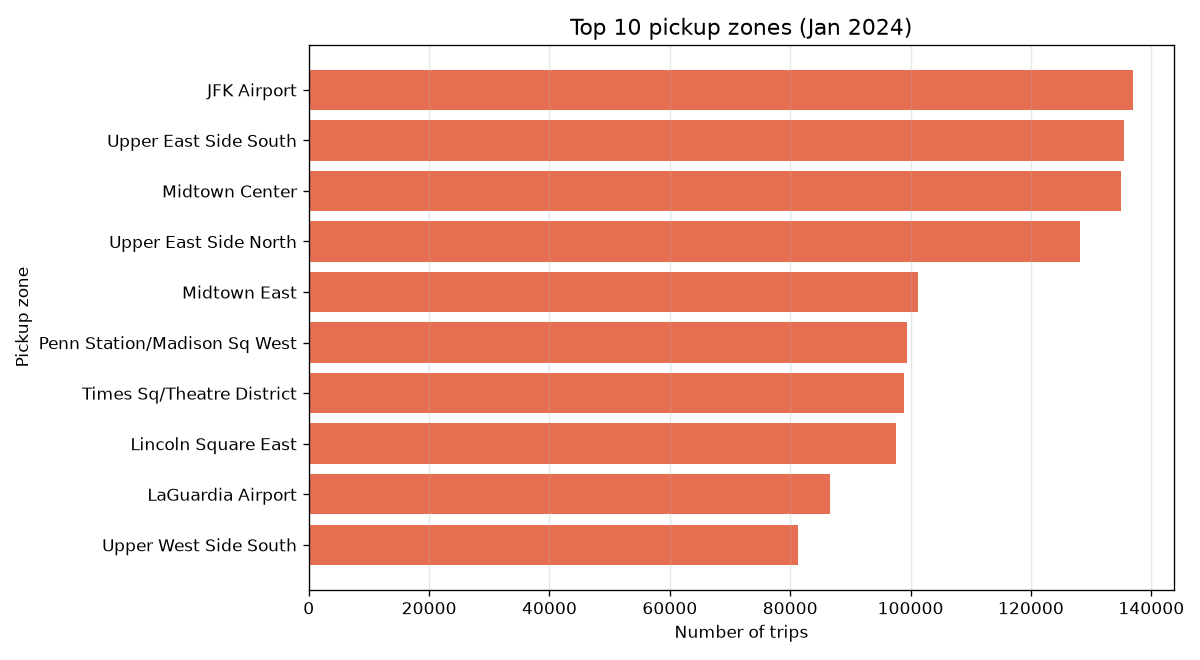

In [7]:
display(res["zones"]); display(Image(CH + "top_pickup_zones.png"))

**Insight:** JFK Airport leads (about 137k pickups), closely followed by Upper East Side South and Midtown Center; both airports appear in the top 10.

## 4. Average fare and distance by hour

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_hour,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,...,14.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00
avg_fare,19.71,17.36,16.36,17.88,23.01,27.58,21.99,18.55,17.59,17.86,...,19.24,19.08,19.44,18.07,16.96,17.64,18.08,18.36,19.16,20.38
avg_distance,3.89,3.25,3.02,3.46,4.79,6.21,4.72,3.54,3.06,3.04,...,3.43,3.28,3.40,3.07,2.87,3.18,3.37,3.47,3.69,4.07


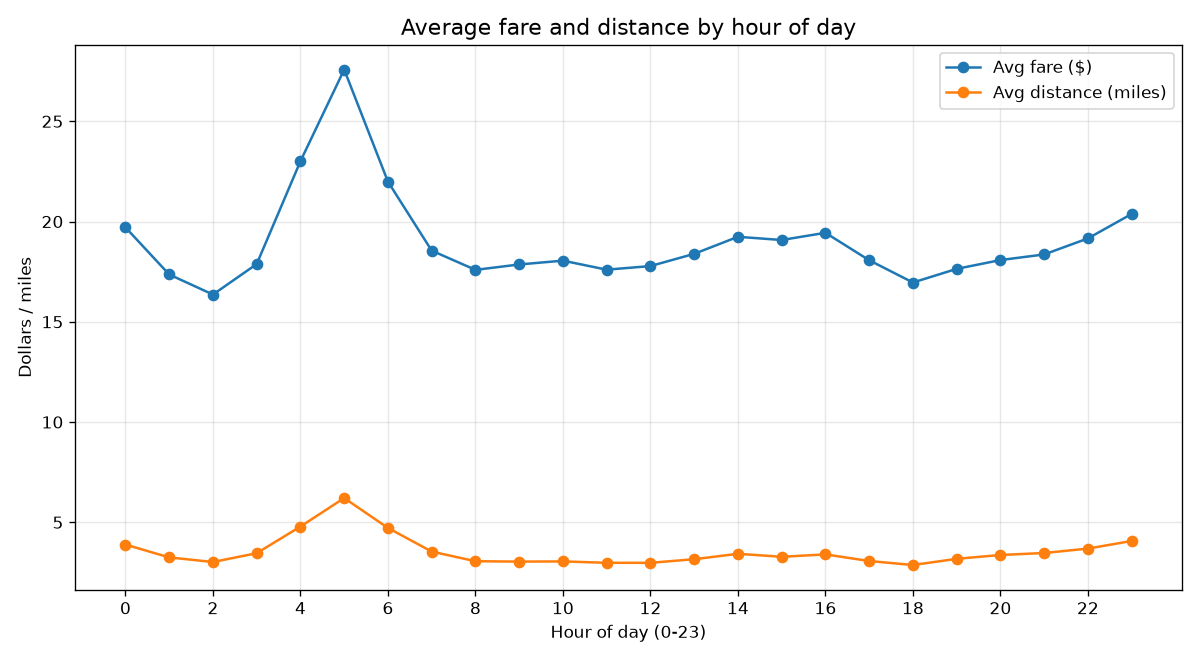

In [8]:
display(res["fare_dist"].T); display(Image(CH + "avg_fare_distance_by_hour.png"))

**Insight:** The longest, priciest trips start at 05:00 (about $27.58, 6.2 miles) - early airport runs - while mid-day trips are short (about 3 miles, $18).

## 5. Payment type distribution

,payment,trips,pct
0,Credit card,2273572,83.47
1,Cash,417812,15.34
2,Dispute,22607,0.83
3,No charge,9806,0.36


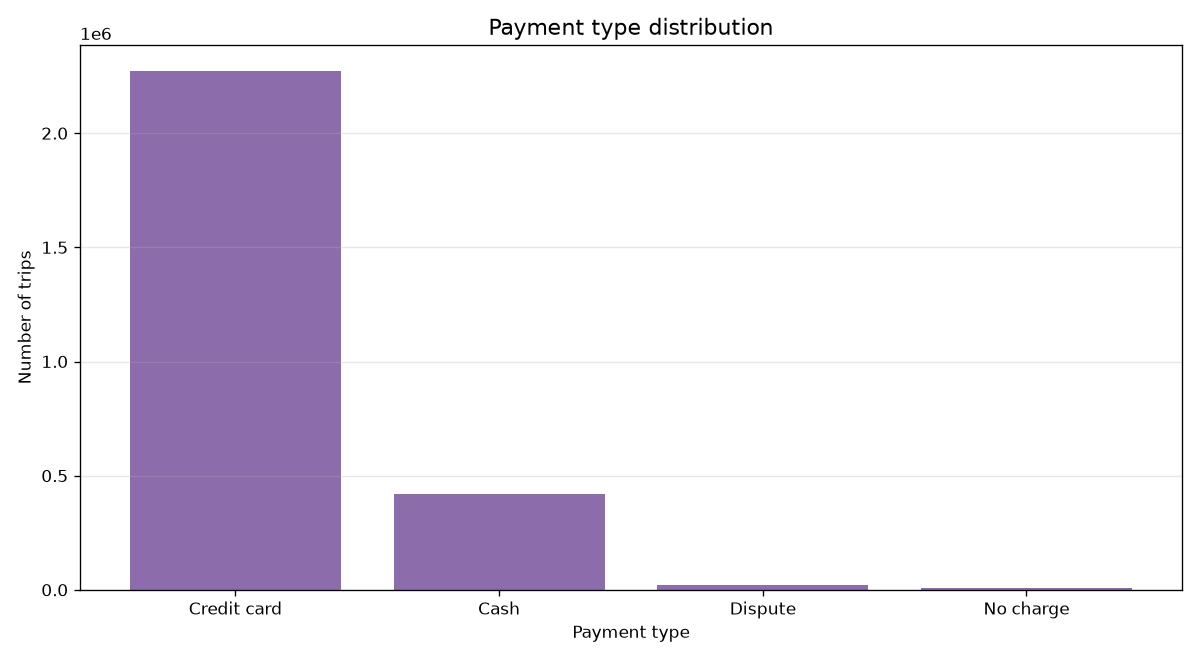

In [9]:
display(res["payment"]); display(Image(CH + "payment_distribution.png"))

**Insight:** Credit cards account for 83.5% of trips and cash for 15.3%.

## 6. Average tip %

,payment,avg_tip_pct,trips
0,Credit card,25.66,2273572
1,Cash,0.00,417812
2,Dispute,0.03,22607
3,No charge,0.04,9806


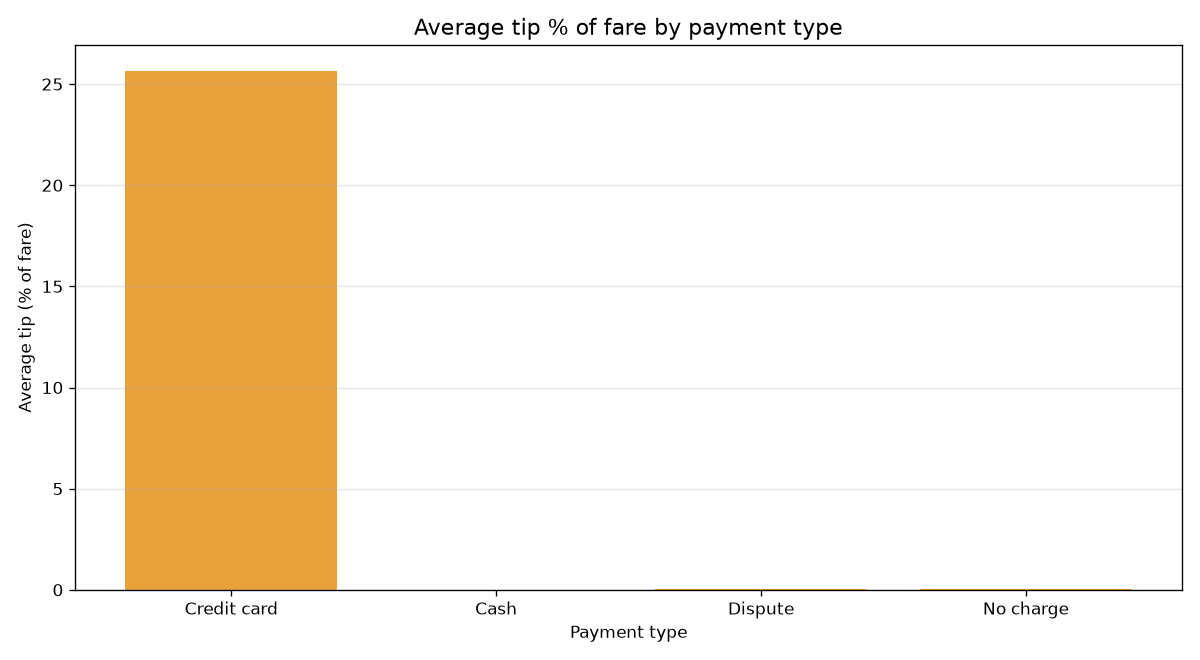

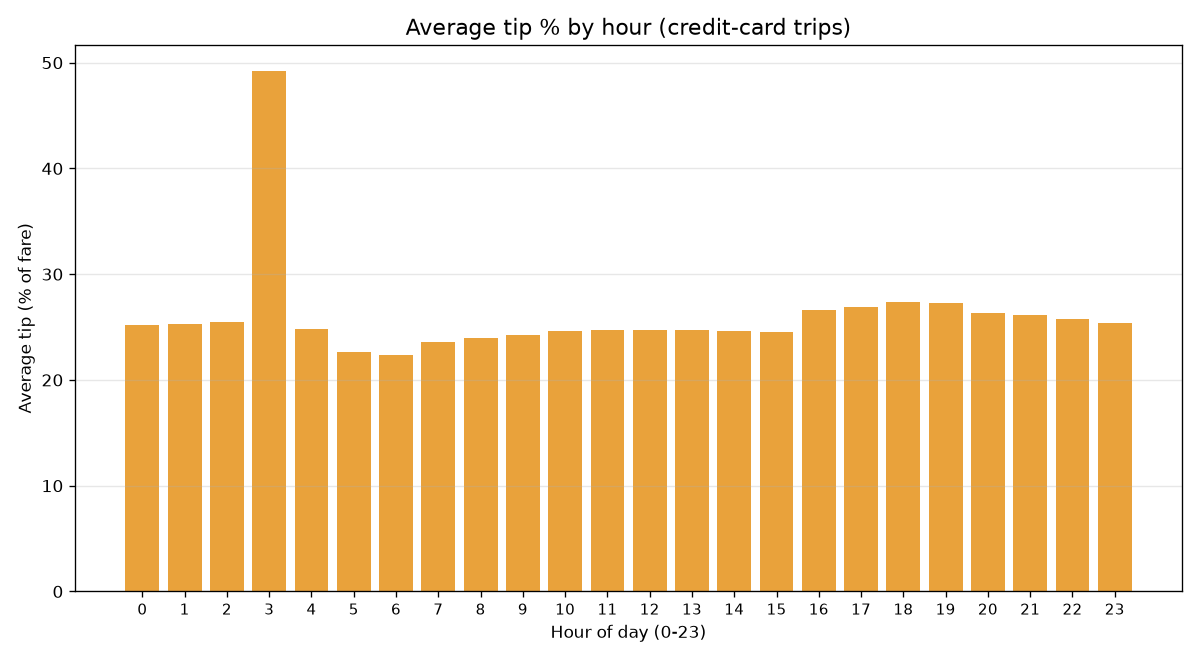

In [10]:
display(res["tip_payment"]); display(Image(CH + "tip_pct_by_payment.png"))
display(Image(CH + "tip_pct_by_hour.png"))

**Insight:** Credit-card riders tip about 25.7% of the fare on average; cash tips are not recorded (0%), so tip analysis only reflects card payments. Evening trips (16:00-20:00) tip slightly more (about 26-27%). The 03:00 spike is driven by few trips with outlier tips.

## Conclusion
- One month of taxi data (~3M rows) was loaded, cleaned and aggregated with PySpark in a few minutes on a laptop.
- Demand is strongly time-dependent (evening peak, mid-week high) and concentrated in a handful of zones.
- The same code would run unchanged on a Hadoop/YARN cluster reading from HDFS; see `docs/report.md`.

In [11]:
spark.stop()